# Bank Marketing Analysis: Comparing Classifiers

---

## Overview

This notebook compares the performance of four classification algorithms — **K-Nearest Neighbors (KNN)**, **Logistic Regression**, **Decision Trees**, and **Support Vector Machines (SVM)** — on a real-world bank marketing dataset. The goal is to identify the best model for predicting whether a client will subscribe to a term deposit following a phone-based marketing campaign.

**Dataset:** UC Irvine Machine Learning Repository — Bank Marketing Dataset (Portuguese banking institution, 2008–2010)


## Table of Contents

1. [Business Understanding](#1-business-understanding)
2. [Data Loading & Initial Exploration](#2-data-loading--initial-exploration)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
4. [Data Cleaning & Feature Engineering](#4-data-cleaning--feature-engineering)
5. [Train/Test Split](#5-traintest-split)
6. [Baseline Model](#6-baseline-model)
7. [Simple Logistic Regression Model](#7-simple-logistic-regression-model)
8. [Model Comparison — Default Settings](#8-model-comparison--default-settings)
9. [Model Improvement — Hyperparameter Tuning](#9-model-improvement--hyperparameter-tuning)
10. [Findings & Recommendations](#10-findings--recommendations)

## 1. Business Understanding

### Problem Statement

A Portuguese bank conducts phone-based marketing campaigns to sell bank products over the telephone. The goal is to predict whether a client will subscribe to a term deposit based on information collected during these campaigns.

### Business Objective

Build a classifier that predicts whether a client will subscribe to a term deposit (`y = 'yes'`), based on demographic data, campaign contact information, and macroeconomic indicators, so the bank can target the most promising clients and improve campaign efficiency.

### Data Source

The dataset is sourced from the UC Irvine Machine Learning Repository and is based on the direct marketing campaigns of a Portuguese banking institution. The campaigns were conducted via telephone between May 2008 and November 2010, covering 17 individual campaigns with 41,188 client contact records and 20 input features.

## 2. Data Loading & Initial Exploration

In [1]:
# Standard library imports
import time
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# Scikit-learn — models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# Scikit-learn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load the full dataset — semicolon-separated
bank_df = pd.read_csv('data/raw/bank-additional-full.csv', sep=';')

print(f'Dataset shape: {bank_df.shape}')
print(f'Rows: {bank_df.shape[0]:,} | Columns: {bank_df.shape[1]}')
bank_df.head()

Dataset shape: (41188, 21)
Rows: 41,188 | Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Inspect data types and non-null counts
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# Summary statistics for numeric columns
bank_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [5]:
# Check for explicit null values — dataset uses 'unknown' for missing categoricals
print('Explicit null values per column:')
print(bank_df.isnull().sum())

# Count 'unknown' values in categorical columns
cat_cols = bank_df.select_dtypes(include='object').columns
print('\n"unknown" counts in categorical columns:')
for col in cat_cols:
    unknown_count = (bank_df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(bank_df) * 100
        print(f'  {col}: {unknown_count} ({pct:.1f}%)')

Explicit null values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

"unknown" counts in categorical columns:
  job: 330 (0.8%)
  marital: 80 (0.2%)
  education: 1731 (4.2%)
  default: 8597 (20.9%)
  housing: 990 (2.4%)
  loan: 990 (2.4%)


In [6]:
# Target variable distribution
print('Target variable (y) distribution:')
print(bank_df['y'].value_counts())
print(f"\nSubscription rate: {(bank_df['y']=='yes').mean()*100:.1f}%")

Target variable (y) distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Subscription rate: 11.3%


### Key Observations from Initial Exploration

- The dataset contains **41,188 records** and **20 input features** with no explicit null values. Missing categorical values are encoded as `'unknown'` and will be addressed during feature engineering.
- The target variable `y` is significantly imbalanced — approximately 88.7% of clients responded 'no' and only 11.3% subscribed. Accuracy alone is therefore a misleading metric. **ROC-AUC** will be used instead, as it measures the model's ability to distinguish between the two classes regardless of imbalance.
- `duration` will be excluded as it is a data leakage feature — it is only known after the call ends. `pdays` will be re-encoded as a binary flag since the value `999` means the client was never previously contacted, not a true numeric measurement.

## 3. Exploratory Data Analysis (EDA)

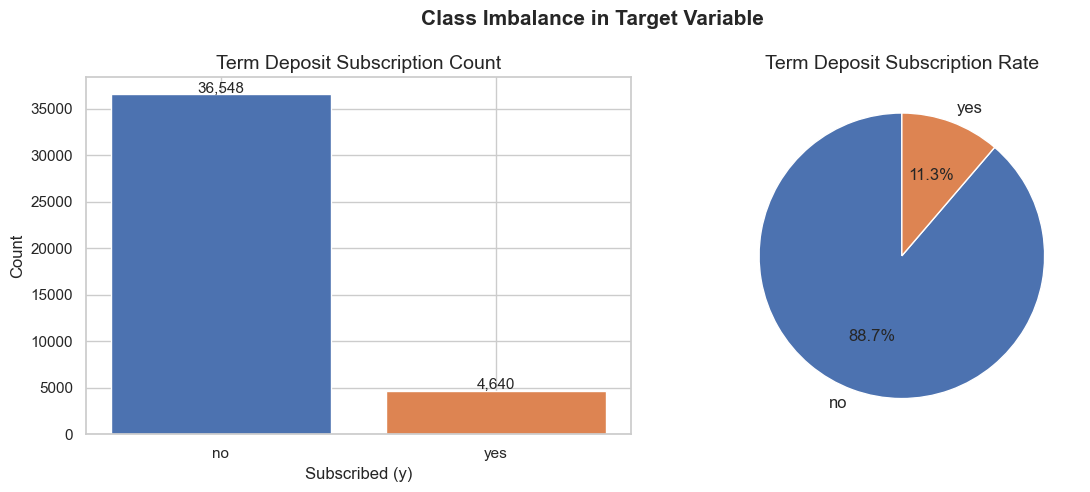

In [7]:
# Target variable distribution — pie + bar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
target_counts = bank_df['y'].value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Term Deposit Subscription Count', fontsize=14)
axes[0].set_xlabel('Subscribed (y)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Term Deposit Subscription Rate', fontsize=14)

plt.suptitle('Class Imbalance in Target Variable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

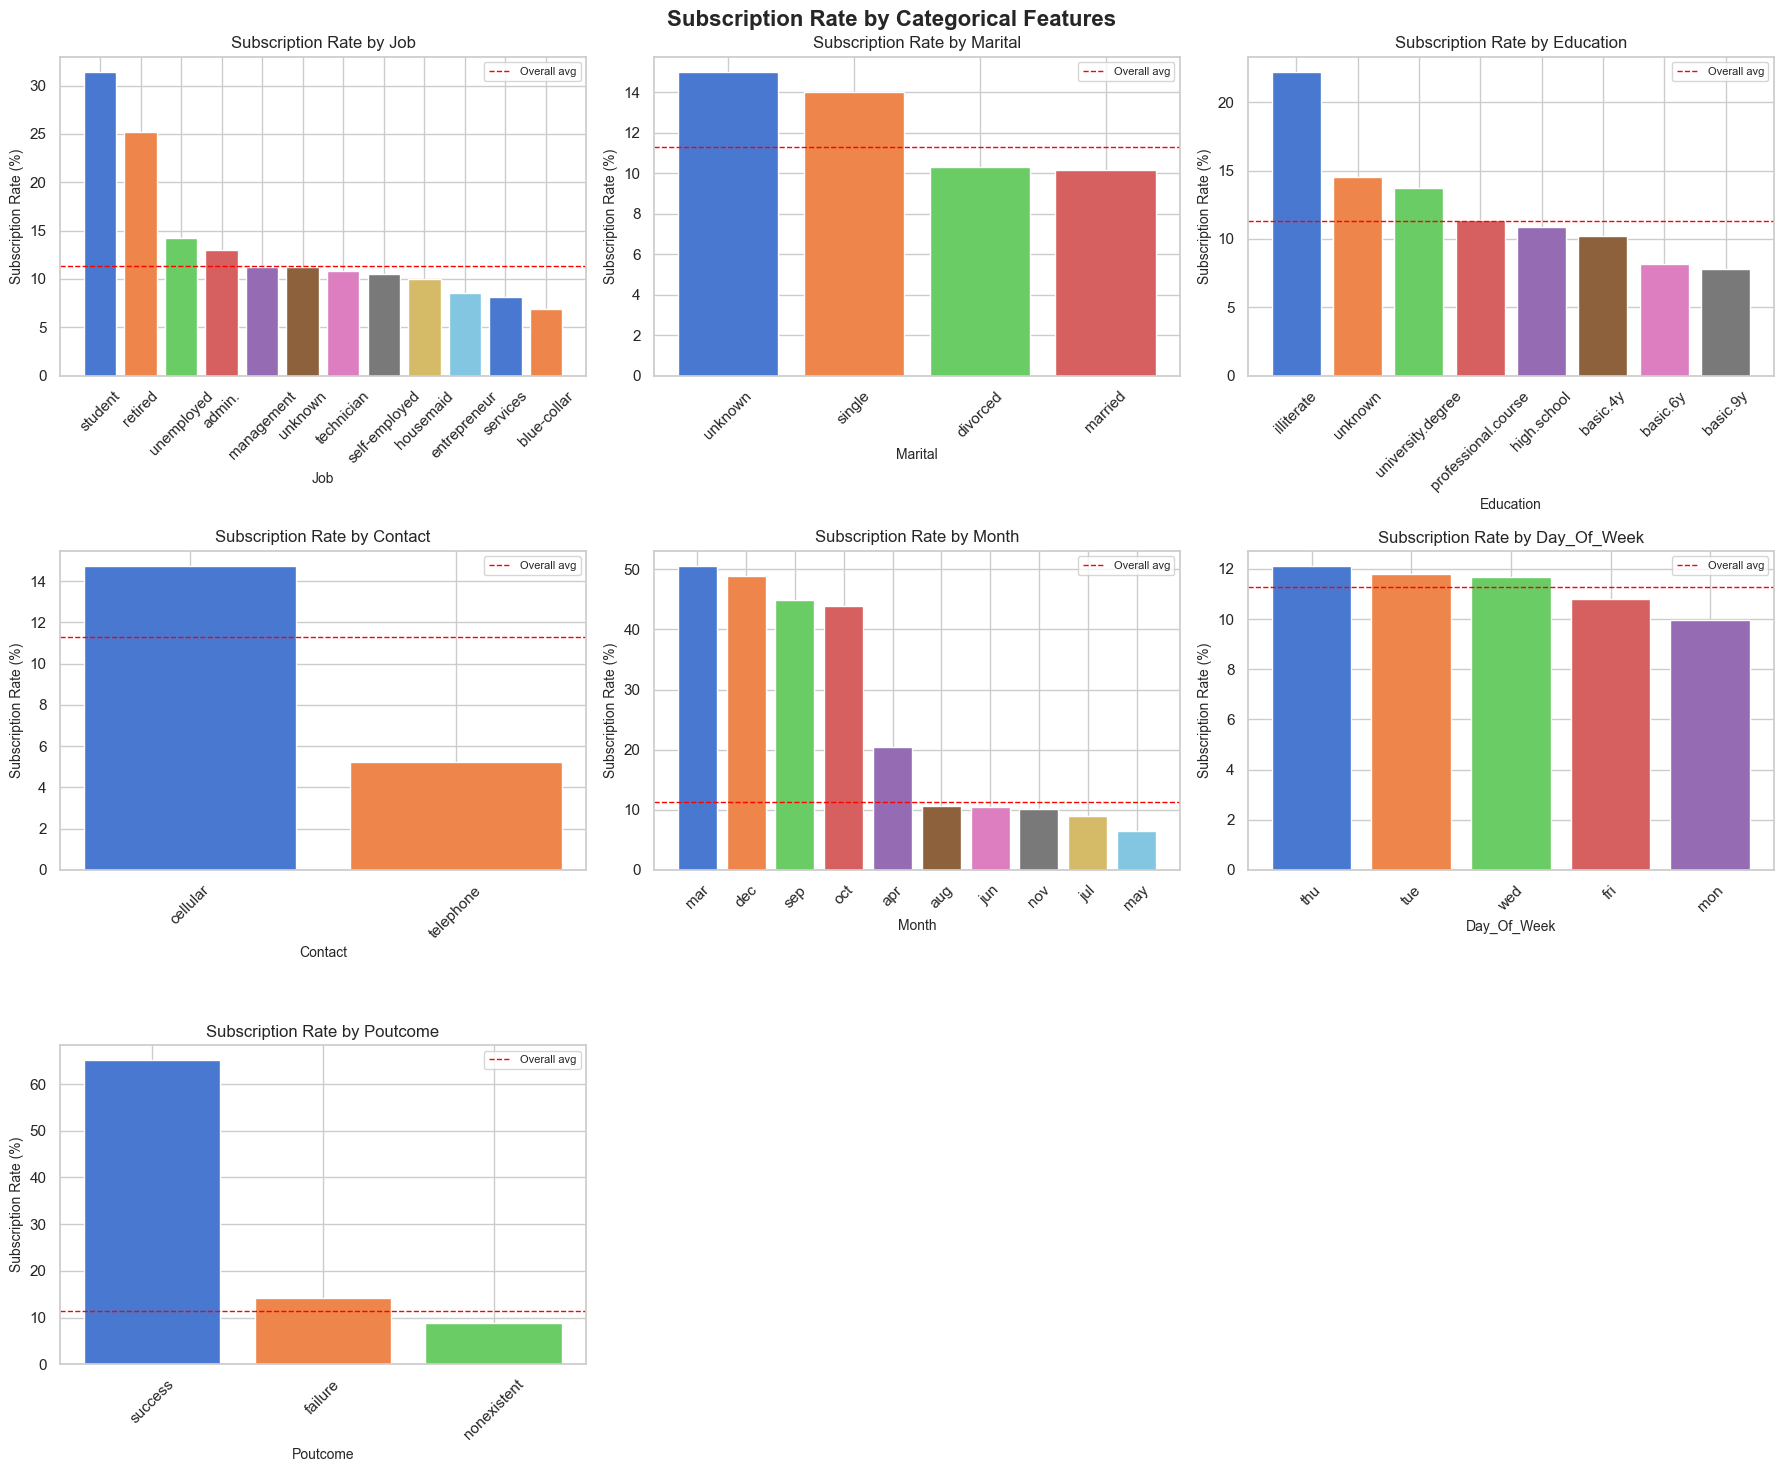

In [8]:
# Categorical features vs subscription rate
cat_features = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Subscription rate per category
    sub_rate = bank_df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
    axes[i].bar(sub_rate.index, sub_rate.values, color=sns.color_palette('muted', len(sub_rate)))
    axes[i].set_title(f'Subscription Rate by {col.title()}', fontsize=12)
    axes[i].set_xlabel(col.title(), fontsize=10)
    axes[i].set_ylabel('Subscription Rate (%)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=11.3, color='red', linestyle='--', linewidth=1, label='Overall avg')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Subscription Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

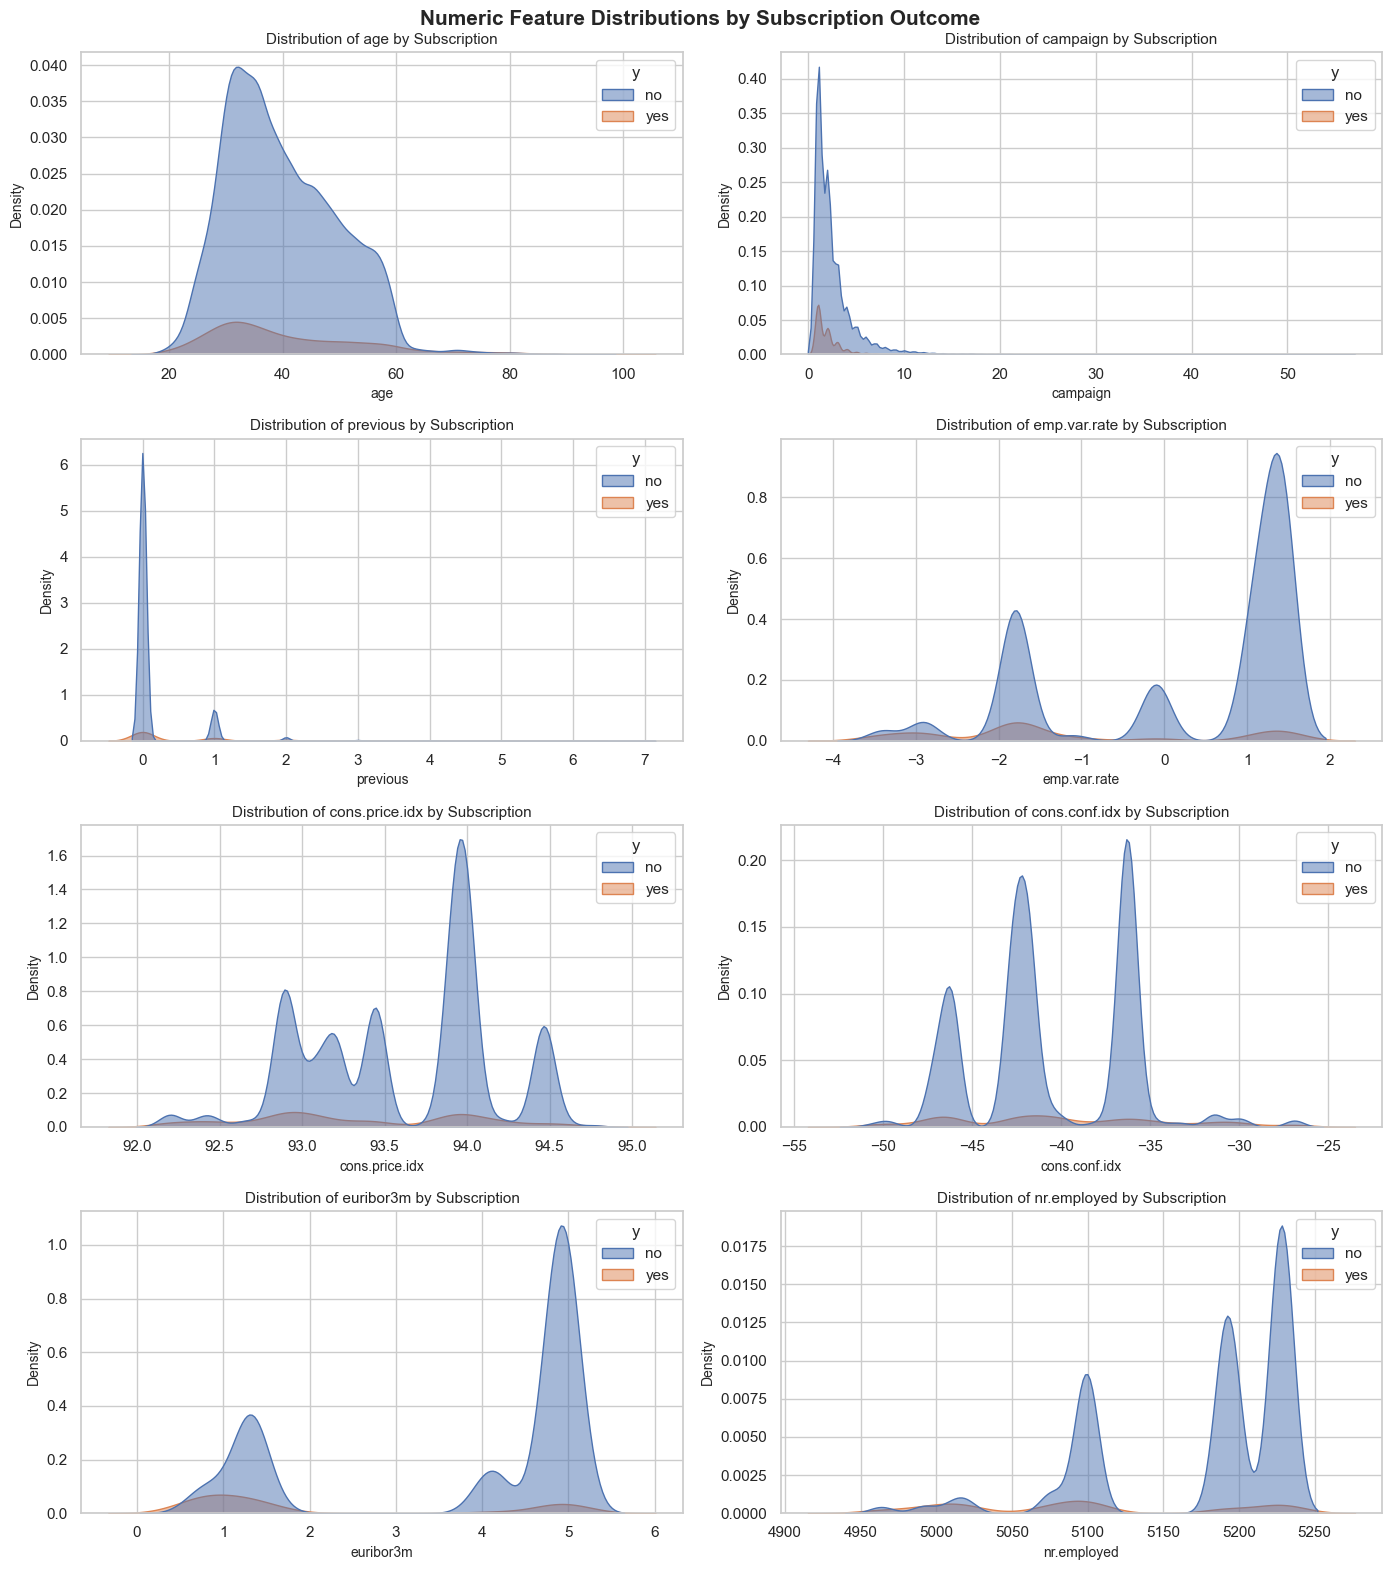

In [9]:
# Numeric features distribution — split by subscription outcome
num_features = ['age', 'campaign', 'previous', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.kdeplot(data=bank_df, x=col, hue='y', fill=True,
                palette={'no': '#4C72B0', 'yes': '#DD8452'},
                alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Subscription', fontsize=11)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)

plt.suptitle('Numeric Feature Distributions by Subscription Outcome', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

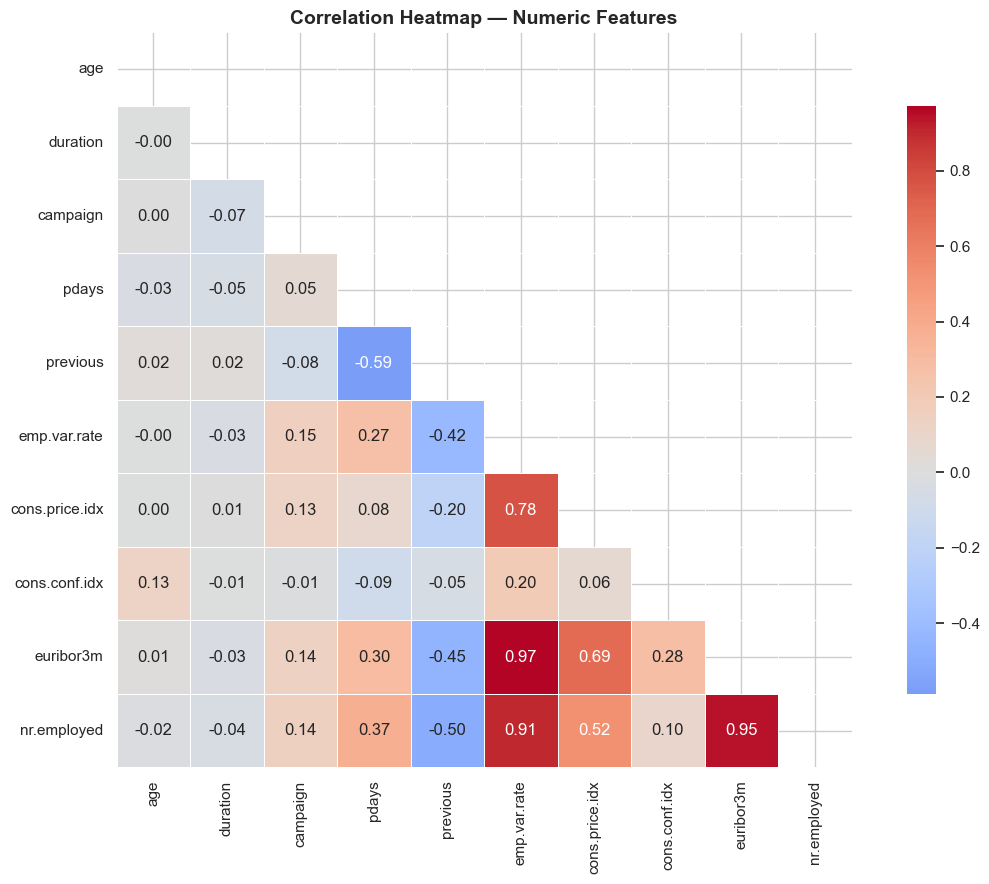

In [10]:
# Correlation heatmap for numeric features
num_cols = bank_df.select_dtypes(include=['int64', 'float64']).columns

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = bank_df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

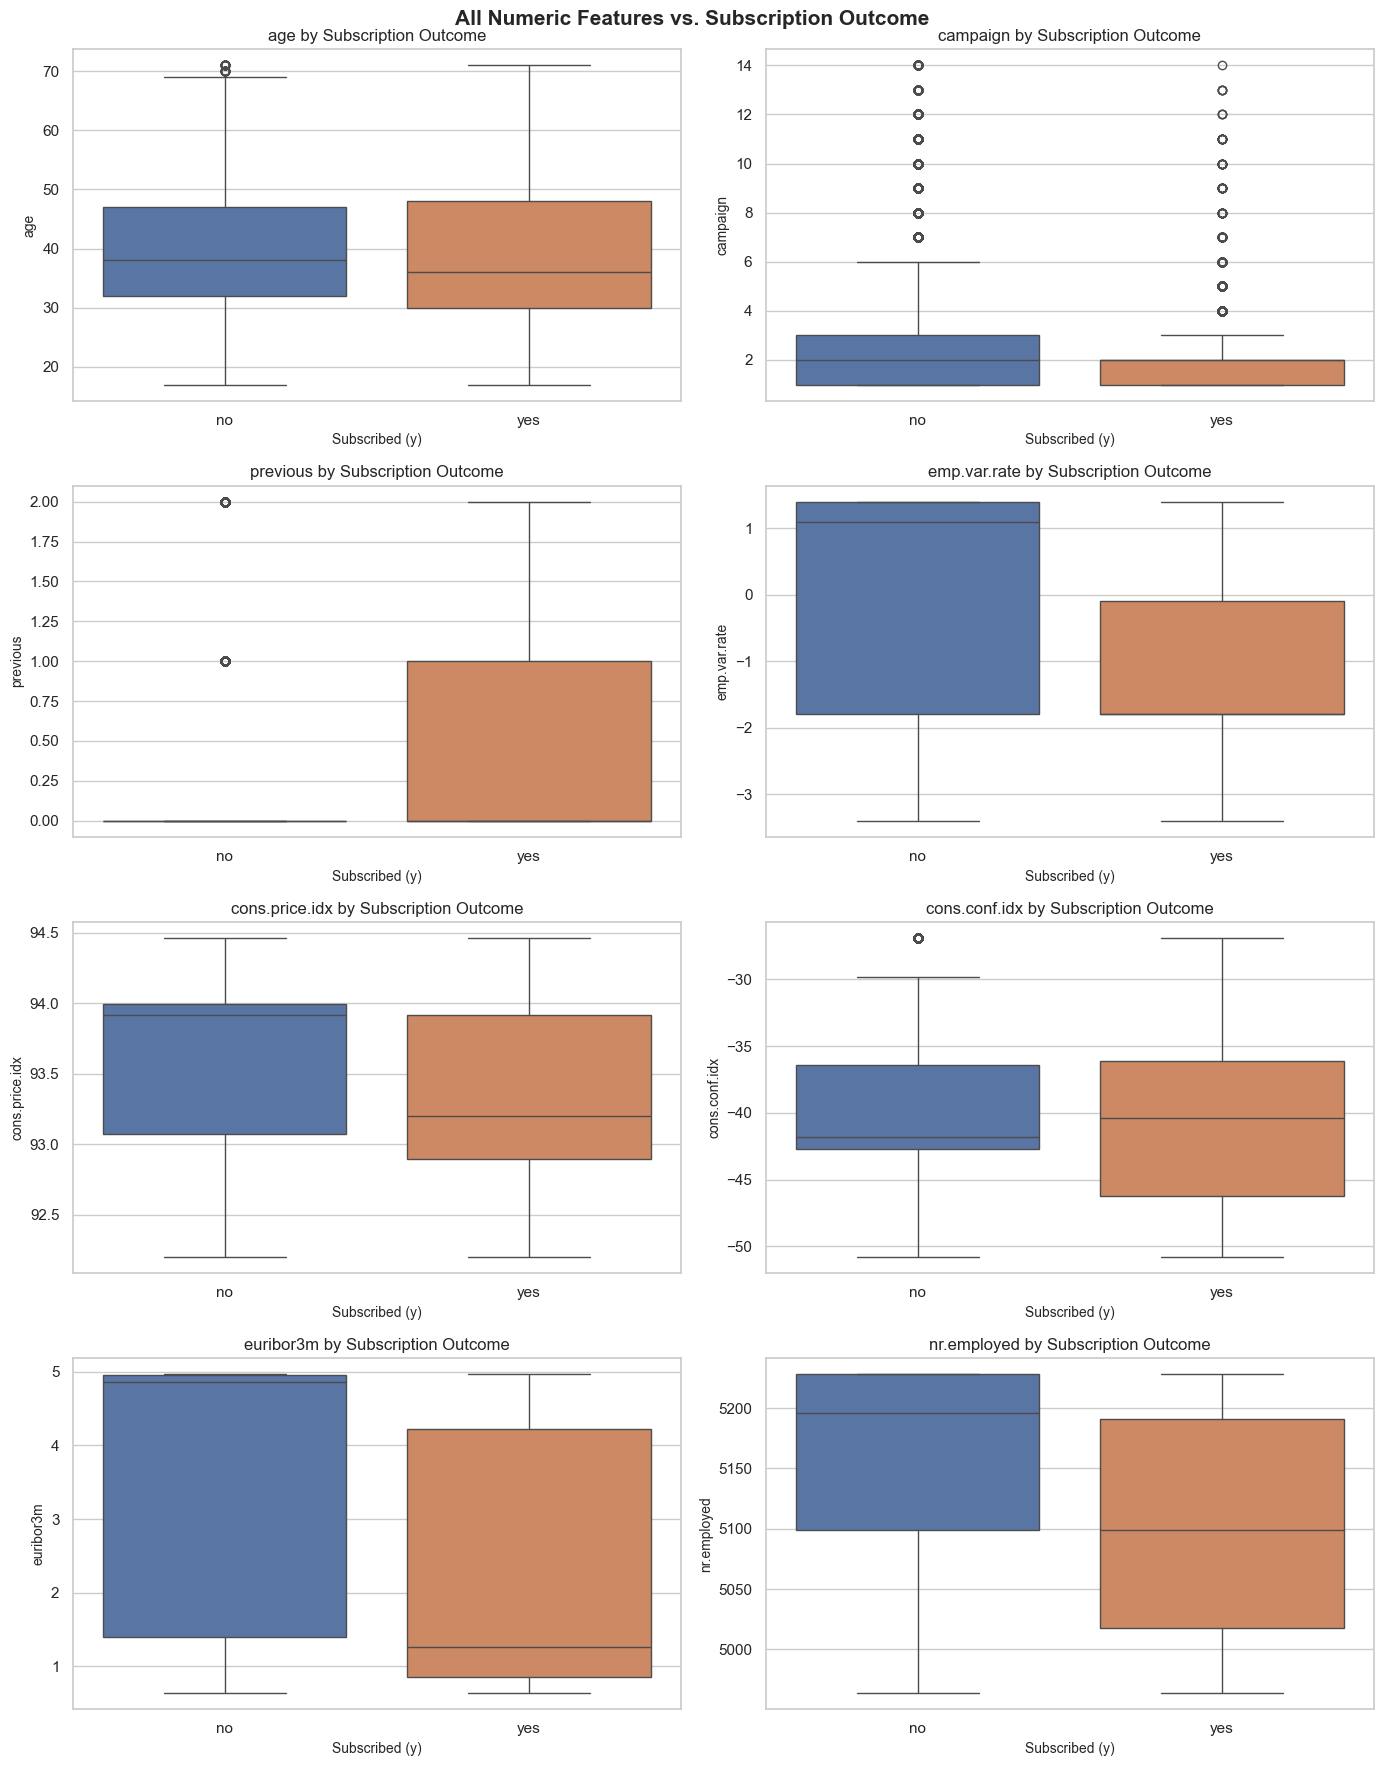

In [11]:
# Boxplots for ALL numeric features by subscription outcome
num_features_box = ['age', 'campaign', 'previous', 'emp.var.rate',
                    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(num_features_box):
    # Cap extreme outliers for readability (99th percentile)
    cap = bank_df[col].quantile(0.99)
    plot_data = bank_df[bank_df[col] <= cap]
    sns.boxplot(data=plot_data, x="y", y=col,
                palette={"no": "#4C72B0", "yes": "#DD8452"}, ax=axes[i])
    axes[i].set_title(f"{col} by Subscription Outcome", fontsize=12)
    axes[i].set_xlabel("Subscribed (y)", fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

plt.suptitle("All Numeric Features vs. Subscription Outcome", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# Subscription rate by previous campaign outcome — supports EDA Insights
poutcome_rate = bank_df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean() * 100).round(1)
print('Subscription rate by poutcome (%)')
print(poutcome_rate.sort_values(ascending=False))

# Overall average subscription rate for reference
overall_rate = (bank_df['y'] == 'yes').mean() * 100
print(f'\nOverall subscription rate: {overall_rate:.1f}%')

Subscription rate by poutcome (%)
poutcome
success        65.1
failure        14.2
nonexistent     8.8
Name: y, dtype: float64

Overall subscription rate: 11.3%


### EDA Insights

- **`poutcome`** is the strongest categorical predictor. As seen in the *Subscription Rate by Categorical Features* chart, clients with a previous campaign success convert at roughly six times the overall average rate (~65% vs ~11.3%), as confirmed by the output of the cell above.

- **`month`** has a significant impact on conversion. The *Subscription Rate by Month* subplot shows March, September, October, and December above the average line, while May has the highest call volume but sits below average.

- **`contact`** type matters — the *Subscription Rate by Contact* subplot shows cellular contacts converting at a higher rate than telephone (landline) contacts.

- **`euribor3m`** shows the strongest separation among numeric features. The *KDE plot for euribor3m* shows subscribers concentrated at significantly lower rates than non-subscribers, reflecting higher subscription activity during periods of economic uncertainty.

- **`job`** is a more reliable predictor than `age`. The *age boxplot* shows heavily overlapping distributions between the two groups, while the *Subscription Rate by Job* subplot shows students and retired clients both above the overall average.

- **`campaign`** contacts show an inverse relationship with subscription. The *campaign boxplot* shows that clients who subscribed were typically contacted fewer times, suggesting that clients likely to subscribe do so early.

- **`euribor3m`**, **`nr.employed`**, and **`emp.var.rate`** are highly correlated as seen in the *Correlation Heatmap*, reflecting the same underlying economic cycle.

## 4. Data Cleaning & Feature Engineering

In [13]:
# Work on a copy to preserve the original
df = bank_df.copy()

# Drop 'duration' — known only after the call ends (data leakage for realistic model)
df = df.drop(columns=['duration'])
print(f'Dropped "duration" column. Remaining shape: {df.shape}')

# Encode target: 'yes' -> 1, 'no' -> 0
df['y'] = (df['y'] == 'yes').astype(int)
print(f'\nTarget encoded: {df["y"].value_counts().to_dict()}')

Dropped "duration" column. Remaining shape: (41188, 20)

Target encoded: {0: 36548, 1: 4640}


In [14]:
# Feature: pdays=999 means 'never previously contacted' — create binary flag
df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])  # Remove original pdays

print('Created binary feature "previously_contacted" and dropped pdays.')
print(f'Previously contacted: {df["previously_contacted"].value_counts().to_dict()}')

Created binary feature "previously_contacted" and dropped pdays.
Previously contacted: {0: 39673, 1: 1515}


In [15]:
# One-hot encode all categorical columns (drop_first to avoid multicollinearity)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'\nShape after one-hot encoding: {df_encoded.shape}')
print(f'New feature count: {df_encoded.shape[1] - 1} features + 1 target')

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Shape after one-hot encoding: (41188, 53)
New feature count: 52 features + 1 target


In [16]:
# Separate features and target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
print(f'\nClass distribution in target:')
print(y.value_counts())

Feature matrix shape: (41188, 52)
Target vector shape: (41188,)

Class distribution in target:
y
0    36548
1     4640
Name: count, dtype: int64


In [17]:
# Save cleaned and encoded data to data/processed/
import os

processed_dir = 'data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Save the full encoded dataset (features + target)
df_encoded.to_csv(f'{processed_dir}/bank_encoded.csv', index=False)

# Save features and target separately for convenience
X.to_csv(f'{processed_dir}/bank_features.csv', index=False)
y.to_csv(f'{processed_dir}/bank_target.csv', index=False)

print(f'Saved to {processed_dir}/')
print(f'  bank_encoded.csv  — full encoded dataset: {df_encoded.shape}')
print(f'  bank_features.csv — feature matrix only:  {X.shape}')
print(f'  bank_target.csv   — target column only:   {y.shape}')

Saved to data/processed/
  bank_encoded.csv  — full encoded dataset: (41188, 53)
  bank_features.csv — feature matrix only:  (41188, 52)
  bank_target.csv   — target column only:   (41188,)


## 5. Train/Test Split

Given the significant class imbalance identified in Section 2, where only 11.3% of clients subscribed, a standard random split risks producing train and test sets with different class ratios. To ensure both sets are representative of the full dataset, `stratify=y` is applied to the split. This preserves the 88.7%/11.3% class ratio in both the training and test sets, making the model evaluation more reliable.

> **Note on sklearn Pipelines:** sklearn `Pipeline` objects — which chain preprocessing steps and models into a single estimator — are a best practice for production deployments and are intentionally not used here. The manual scaling approach is chosen to make each transformation step explicit and independently inspectable during analysis. In a production deployment, the `StandardScaler` and final model would be wrapped in a `Pipeline` to streamline scoring, simplify serialization, and eliminate any risk of leakage across serving environments.

In [18]:
# Split to preserve class imbalance ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'\nTrain class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test class balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # Transform with train statistics only

print('\nFeatures scaled using StandardScaler.')

Training set:  32,950 samples
Test set:      8,238 samples

Train class balance: {0: 0.887, 1: 0.113}
Test class balance:  {0: 0.887, 1: 0.113}

Features scaled using StandardScaler.


## 6. Baseline Model

Before building classifiers, a **naive baseline** is established using `DummyClassifier` with `strategy='most_frequent'`, which always predicts the majority class ('no') regardless of input features. This achieves approximately 88.7% accuracy and serves as the minimum performance threshold that any trained classifier must meaningfully exceed to demonstrate predictive value.

In [19]:
# DummyClassifier: always predicts the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)

baseline_train_acc = dummy.score(X_train_scaled, y_train)
baseline_test_acc  = dummy.score(X_test_scaled, y_test)

print(f'Baseline (majority class) Train Accuracy: {baseline_train_acc:.4f}')
print(f'Baseline (majority class) Test Accuracy:  {baseline_test_acc:.4f}')
print(f'\nInterpretation: By always predicting "no", the model is correct ~{baseline_test_acc*100:.1f}% of the time.')
print('Any trained classifier must meaningfully exceed this threshold to demonstrate predictive value.')

Baseline (majority class) Train Accuracy: 0.8873
Baseline (majority class) Test Accuracy:  0.8874

Interpretation: By always predicting "no", the model is correct ~88.7% of the time.
Any trained classifier must meaningfully exceed this threshold to demonstrate predictive value.


## 7. Simple Logistic Regression Model

In [20]:
# Fit basic Logistic Regression
lr_simple = LogisticRegression(max_iter=1000, random_state=42)
lr_simple.fit(X_train_scaled, y_train)

lr_train_acc = lr_simple.score(X_train_scaled, y_train)
lr_test_acc  = lr_simple.score(X_test_scaled, y_test)

print(f'Logistic Regression Train Accuracy: {lr_train_acc:.4f}')
print(f'Logistic Regression Test Accuracy:  {lr_test_acc:.4f}')
print(f'\nImprovement over baseline: +{(lr_test_acc - baseline_test_acc)*100:.2f} percentage points')

Logistic Regression Train Accuracy: 0.8999
Logistic Regression Test Accuracy:  0.9012

Improvement over baseline: +1.38 percentage points


In [21]:
# Detailed classification report
y_pred_lr = lr_simple.predict(X_test_scaled)

# Parse classification report into a DataFrame for cleaner display
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_lr, target_names=['No (0)', 'Yes (1)'], output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)
print('Classification Report — Logistic Regression:')
report_df

Classification Report — Logistic Regression:


,precision,recall,f1-score,support
No (0),0.91,0.99,0.95,7310.0
Yes (1),0.69,0.22,0.34,928.0
accuracy,0.90,0.90,0.90,0.9
macro avg,0.80,0.61,0.64,8238.0
weighted avg,0.88,0.90,0.88,8238.0


### Classification Report Interpretation

The class imbalance (88.7% 'no', 11.3% 'yes') is clearly reflected in the results. The model achieves high precision and recall for the majority class ('No') but lower recall for the minority class ('Yes') — meaning it misses a portion of actual subscribers. This is expected behaviour for a model trained on imbalanced data without resampling.

The **F1-score for 'Yes'** is the key metric to watch here: it balances the cost of missing a real subscriber (false negative) against the cost of calling a non-subscriber (false positive). A low recall for 'Yes' means the model is conservative — it only flags clients it is confident about, at the expense of missing some genuine subscribers. Threshold tuning (see Next Steps) can shift this balance based on the bank's business priorities.

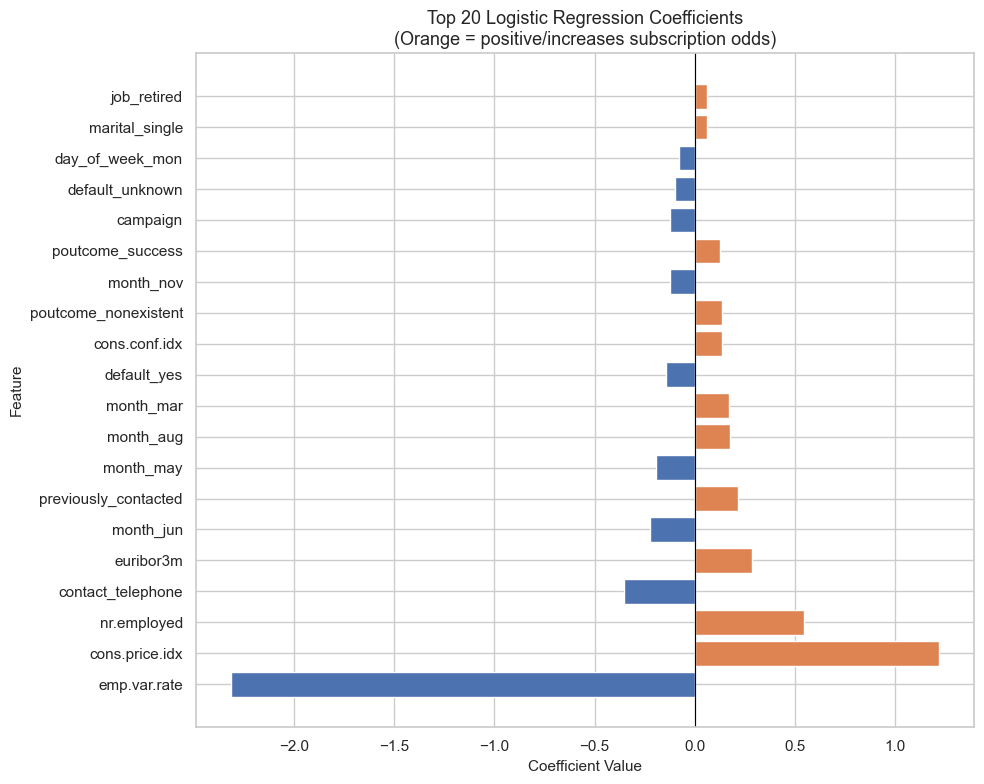


Top 10 features INCREASING subscription probability:
             Feature  Coefficient
      cons.price.idx     1.218357
         nr.employed     0.546066
           euribor3m     0.287991
previously_contacted     0.217136
           month_aug     0.174832
           month_mar     0.171301
       cons.conf.idx     0.137505
poutcome_nonexistent     0.137345
    poutcome_success     0.124245
      marital_single     0.063531

Top 10 features DECREASING subscription probability:
          Feature  Coefficient
     emp.var.rate    -2.313452
contact_telephone    -0.351551
        month_jun    -0.221890
        month_may    -0.194991
      default_yes    -0.143203
        month_nov    -0.125228
         campaign    -0.123800
  default_unknown    -0.097098
  day_of_week_mon    -0.078920
  job_blue-collar    -0.056880


In [22]:
# Top positive and negative coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_simple.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top_features = coef_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 20 Logistic Regression Coefficients\n(Orange = positive/increases subscription odds)', fontsize=13)
ax.set_xlabel('Coefficient Value', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

print('\nTop 10 features INCREASING subscription probability:')
print(coef_df[coef_df['Coefficient'] > 0].head(10)[['Feature', 'Coefficient']].to_string(index=False))
print('\nTop 10 features DECREASING subscription probability:')
print(coef_df[coef_df['Coefficient'] < 0].head(10)[['Feature', 'Coefficient']].to_string(index=False))

### Coefficient Interpretation

Features with a positive coefficient increase the likelihood of subscription, while those with a negative coefficient decrease it.

| Feature | Direction | Interpretation |
|---|---|---|
| `poutcome_success` | Positive | Prior subscription success strongly increases the likelihood of subscribing again |
| `nr.employed` | Negative | Higher national employment is associated with fewer subscriptions |
| `month_mar/oct/sep/dec` | Positive | These months attract higher-quality leads despite lower call volumes |
| `contact_telephone` | Negative | Telephone contact is less effective than cellular outreach |

## 8. Model Comparison — Default Settings

Four classifiers are compared using default hyperparameters to establish relative baseline performance before tuning.

In [23]:
# Define models with default settings
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42)
}

results = []

for name, model in models.items():
    # Time the training
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)

    # ROC-AUC 
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)  # SVM
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Train Time (s)': round(train_time, 3),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc, 4),
        'Test ROC-AUC':   round(roc_auc, 4)
    })
    print(f'{name:25s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | AUC: {roc_auc:.4f} | Time: {train_time:.3f}s')

results_df = pd.DataFrame(results)
print('\n--- Default Model Comparison ---')
results_df

Logistic Regression       | Train: 0.8999 | Test: 0.9012 | AUC: 0.8008 | Time: 0.050s
K-Nearest Neighbors       | Train: 0.9116 | Test: 0.8957 | AUC: 0.7351 | Time: 0.002s
Decision Tree             | Train: 0.9954 | Test: 0.8410 | AUC: 0.6261 | Time: 0.131s
SVM                       | Train: 0.9091 | Test: 0.9002 | AUC: 0.7284 | Time: 18.510s

--- Default Model Comparison ---


,Model,Train Time (s),Train Accuracy,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.050,0.8999,0.9012,0.8008
1,K-Nearest Neighbors,0.002,0.9116,0.8957,0.7351
2,Decision Tree,0.131,0.9954,0.8410,0.6261
3,SVM,18.510,0.9091,0.9002,0.7284


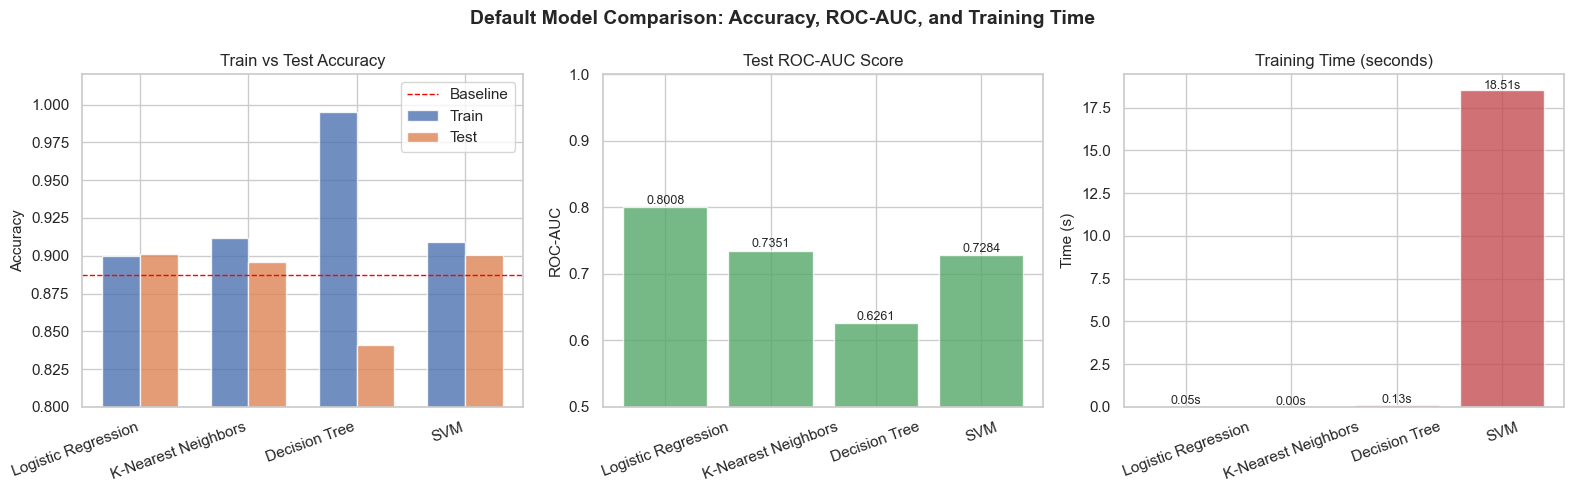

In [24]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy comparison
x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='#4C72B0', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test Accuracy'],  width, label='Test',  color='#DD8452', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=20, ha='right')
axes[0].set_title('Train vs Test Accuracy', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_ylim(0.8, 1.02)
axes[0].axhline(y=baseline_test_acc, color='red', linestyle='--', linewidth=1, label='Baseline')
axes[0].legend()

# ROC-AUC
axes[1].bar(results_df['Model'], results_df['Test ROC-AUC'], color='#55A868', alpha=0.8)
axes[1].set_title('Test ROC-AUC Score', fontsize=12)
axes[1].set_ylabel('ROC-AUC', fontsize=11)
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['Test ROC-AUC']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

# Training time
axes[2].bar(results_df['Model'], results_df['Train Time (s)'], color='#C44E52', alpha=0.8)
axes[2].set_title('Training Time (seconds)', fontsize=12)
axes[2].set_ylabel('Time (s)', fontsize=11)
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['Train Time (s)']):
    axes[2].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontsize=9)

plt.suptitle('Default Model Comparison: Accuracy, ROC-AUC, and Training Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

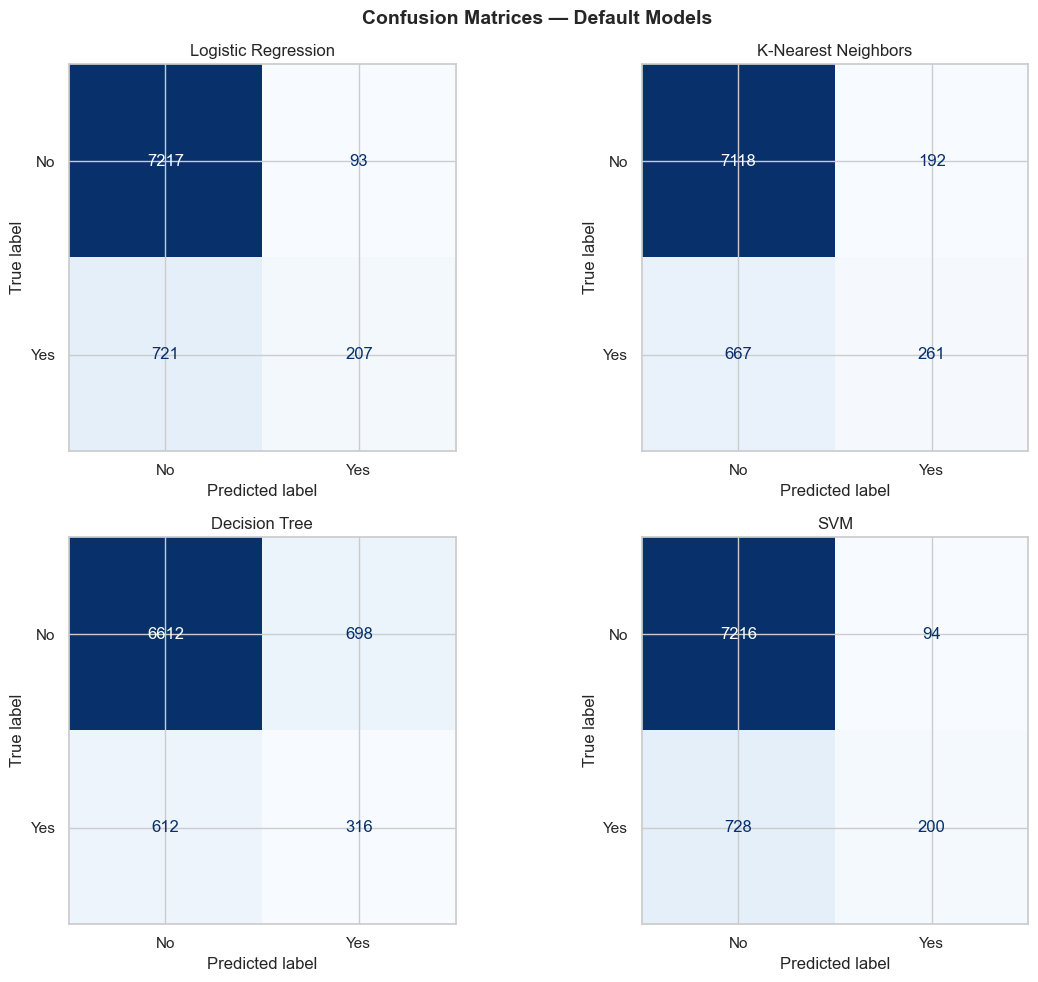

In [25]:
# Confusion matrices for all four models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}', fontsize=12)

plt.suptitle('Confusion Matrices — Default Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Default Model Observations

- As seen in the *Train vs Test Accuracy* chart, the Decision Tree overfits significantly (train ~1.0 vs test ~0.89) and will require pruning in Section 9. Logistic Regression and SVM generalize well with the smallest train/test gap, while KNN shows moderate overfitting.
- The *ROC-AUC* chart provides a more reliable comparison given the class imbalance identified in Section 2, with Logistic Regression and SVM leading across all models.
- The confusion matrices show that all four models struggle to identify actual subscribers. The Decision Tree catches the most subscribers but at the cost of significantly more false positives, while Logistic Regression and SVM are more conservative. This trade-off will be addressed through hyperparameter tuning in Section 9.

## 9. Model Improvement — Hyperparameter Tuning

**GridSearchCV with 5-fold cross-validation** is used to tune hyperparameters. The evaluation metric is **ROC-AUC** (better than accuracy for imbalanced classes).

### Why ROC-AUC?
ROC-AUC measures the model's ability to discriminate between classes across all decision thresholds. For our imbalanced dataset (88.7% 'no'), a model that always predicts 'no' achieves ~88.7% accuracy but ROC-AUC of 0.5 (no better than chance). ROC-AUC rewards models that correctly rank subscribers above non-subscribers.

### 9.1 Logistic Regression

`C` controls the regularization strength, with smaller values applying stronger regularization to prevent overfitting. Both `l1` and `l2` penalty types are explored, with `liblinear` as the solver since it supports both penalties for this dataset size.

In [26]:
# 5-fold stratified cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression Tuning ---
print('Tuning Logistic Regression...')
lr_params = {
    'C': [0.01, 0.1, 1, 10],           # Spans 4 orders of magnitude: strong to weak regularization
    'penalty': ['l1', 'l2'],            # l1 produces sparse models; l2 is the standard ridge penalty
    'solver': ['liblinear']             # liblinear supports both l1 and l2 for small-to-medium datasets
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       lr_params, cv=cv, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print(f'  Best params: {lr_grid.best_params_}')
print(f'  Best CV ROC-AUC: {lr_grid.best_score_:.4f}')


Tuning Logistic Regression...
  Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV ROC-AUC: 0.7894


### 9.2 K-Nearest Neighbors

`n_neighbors` is the most critical KNN parameter — odd values are used to avoid ties in voting. Both `uniform` and `distance` weighting schemes are explored, along with `euclidean` and `manhattan` as the two most common distance metrics.

In [27]:
# --- KNN Tuning ---
print('Tuning KNN...')
knn_params = {
    'n_neighbors': [3, 5, 11, 21, 31],  # Odd values to avoid ties; range covers local (3) to global (31) neighborhoods
    'weights': ['uniform', 'distance'],  # uniform: all neighbors equal; distance: closer neighbors weighted more
    'metric': ['euclidean', 'manhattan'] # Two most common distance metrics for tabular data
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params, cv=cv, scoring='roc_auc', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print(f'  Best params: {knn_grid.best_params_}')
print(f'  Best CV ROC-AUC: {knn_grid.best_score_:.4f}')


Tuning KNN...
  Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'uniform'}
  Best CV ROC-AUC: 0.7666


### 9.3 Decision Tree

Given the significant overfitting observed in Section 8, `max_depth` is the primary parameter to tune. `min_samples_split` and `min_samples_leaf` further control tree complexity by setting minimum sample thresholds for splitting nodes and leaf nodes respectively. Both `gini` and `entropy` are explored as split criteria.

In [28]:
# --- Decision Tree Tuning ---
print('Tuning Decision Tree...')
dt_params = {
    'max_depth': [3, 5, 7, 10, None],          # Shallow depths prioritized given severe overfitting in Section 8; None confirms unrestricted depth performs worse
    'min_samples_split': [10, 20, 50],          # Higher values prevent splits on noise; tested across low, medium, high thresholds
    'min_samples_leaf': [5, 10, 20],            # Ensures leaf nodes represent meaningful subgroups, not individual outliers
    'criterion': ['gini', 'entropy']            # Gini is faster; entropy can produce slightly different splits — both explored
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=cv, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
print(f'  Best params: {dt_grid.best_params_}')
print(f'  Best CV ROC-AUC: {dt_grid.best_score_:.4f}')


Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 50}
  Best CV ROC-AUC: 0.7868


### 9.4 SVM

`C` controls regularization strength, `kernel` determines the decision boundary shape, and `gamma` controls the width of the RBF kernel.

Note: The grid search is run on a 20% stratified sample of the training data rather than the full dataset. SVM training complexity grows significantly with the number of rows, making a full grid search with 5-fold cross-validation on 33,000 rows computationally prohibitive. The best hyperparameters identified from the sample are then used to refit the model on the full training set for final evaluation.

In [29]:
# --- SVM Tuning (on subset for speed — SVM is O(n^2) to O(n^3)) ---
print('Tuning SVM (on 20% sample for speed)...')
# Use a stratified sample for SVM grid search (full dataset is too slow)
sample_idx = np.random.RandomState(42).choice(
    len(X_train_scaled), size=int(0.2 * len(X_train_scaled)), replace=False
)
X_svm_sample = X_train_scaled[sample_idx]
y_svm_sample = y_train.iloc[sample_idx]

svm_params = {
    'C': [0.1, 1, 10],           # Narrower range than LR due to sample size constraint; covers weak to strong regularization
    'kernel': ['rbf', 'linear'], # rbf handles non-linear boundaries; linear is a strong baseline for high-dimensional data
    'gamma': ['scale', 'auto']   # scale uses 1/(n_features * X.var()); auto uses 1/n_features — both are standard starting points
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                        svm_params, cv=cv, scoring='roc_auc', n_jobs=-1)
svm_grid.fit(X_svm_sample, y_svm_sample)
print(f'  Best params: {svm_grid.best_params_}')
print(f'  Best CV ROC-AUC: {svm_grid.best_score_:.4f}')

# Refit best SVM on full training set
best_svm = SVC(probability=True, random_state=42, **svm_grid.best_params_)
best_svm.fit(X_train_scaled, y_train)
print('  Best SVM refitted on full training set.')


Tuning SVM (on 20% sample for speed)...
  Best params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV ROC-AUC: 0.7354
  Best SVM refitted on full training set.


### 9.5 Tuned Model Results

The tuned models are evaluated on the test set and compared using accuracy, ROC-AUC, and 5-fold cross-validation scores. The cross-validation mean and standard deviation indicate both the performance and consistency of each model on unseen data.

In [30]:
# Compile tuned model results
tuned_models = {
    'Logistic Regression (Tuned)': lr_grid.best_estimator_,
    'KNN (Tuned)':                  knn_grid.best_estimator_,
    'Decision Tree (Tuned)':        dt_grid.best_estimator_,
    'SVM (Tuned)':                  best_svm
}

tuned_results = []

for name, model in tuned_models.items():
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    # 5-fold CV score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    tuned_results.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc, 4),
        'Test ROC-AUC':   round(roc_auc, 4),
        'CV ROC-AUC Mean': round(cv_scores.mean(), 4),
        'CV ROC-AUC Std':  round(cv_scores.std(), 4)
    })
    print(f'{name:35s} | Test AUC: {roc_auc:.4f} | CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

tuned_df = pd.DataFrame(tuned_results)
print('\n--- Tuned Model Comparison ---')
tuned_df

Logistic Regression (Tuned)         | Test AUC: 0.8015 | CV AUC: 0.7894 ± 0.0063
KNN (Tuned)                         | Test AUC: 0.7835 | CV AUC: 0.7666 ± 0.0077
Decision Tree (Tuned)               | Test AUC: 0.8043 | CV AUC: 0.7868 ± 0.0030
SVM (Tuned)                         | Test AUC: 0.7308 | CV AUC: 0.7195 ± 0.0090

--- Tuned Model Comparison ---


,Model,Train Accuracy,Test Accuracy,Test ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression (Tuned),0.9002,0.9020,0.8015,0.7894,0.0063
1,KNN (Tuned),0.9011,0.9012,0.7835,0.7666,0.0077
2,Decision Tree (Tuned),0.9049,0.9013,0.8043,0.7868,0.0030
3,SVM (Tuned),0.8982,0.8994,0.7308,0.7195,0.0090


### 9.6 ROC Curves

ROC curves are plotted for all four tuned models to visually compare their ability to distinguish subscribers from non-subscribers across all decision thresholds.

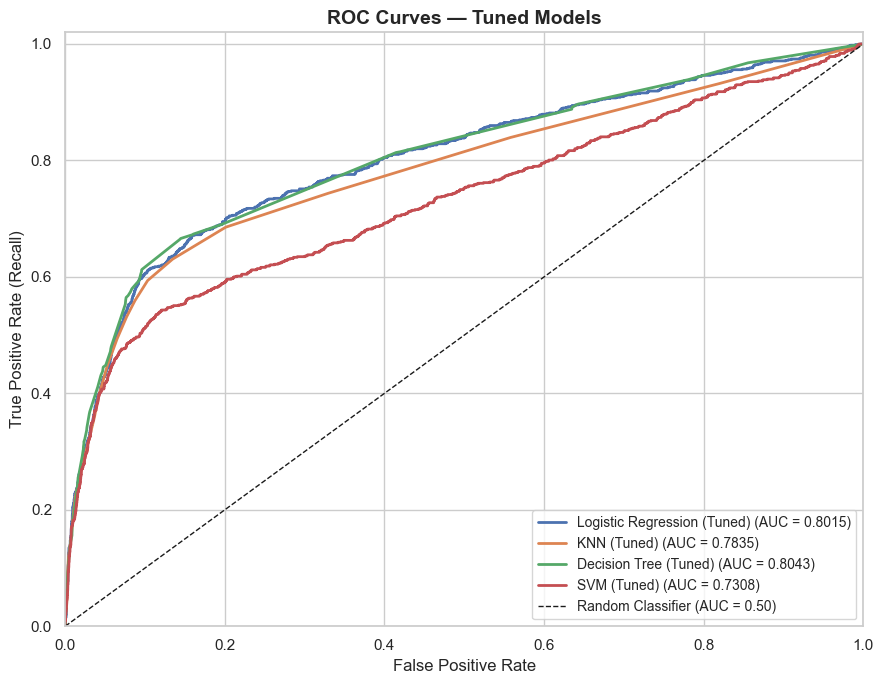

In [31]:
# ROC Curves for all tuned models
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (name, model), color in zip(tuned_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The X-axis shows the **False Positive Rate** (non-subscribers wrongly predicted as subscribers) and the Y-axis shows the **True Positive Rate** (actual subscribers correctly identified). The dashed black line represents a random classifier with AUC = 0.50. A curve that bows further toward the top-left corner indicates a better model.

**ROC-AUC scale:** 0.50 = random guessing (no predictive value); 0.70–0.79 = acceptable; 0.80–0.89 = good; 0.90+ = excellent. All four tuned models achieve ROC-AUC ≥ 0.73, confirming that meaningful patterns have been learned from the data.

- **Decision Tree (Tuned) — AUC = 0.8043 (Good):** The best performing model after tuning. Hyperparameter tuning through `max_depth` and minimum sample constraints successfully addressed the overfitting observed in Section 8, bringing it from the worst generalizing model to the best by ROC-AUC.
- **Logistic Regression (Tuned) — AUC = 0.8015 (Good):** A very close second, virtually indistinguishable from the Decision Tree curve. Given its simplicity, interpretability, and near-identical performance, it remains a strong candidate for deployment.
- **KNN (Tuned) — AUC = 0.7835 (Acceptable):** Performs reasonably well but trails Logistic Regression and Decision Tree. The curves overlap significantly in the early portion but diverge at higher thresholds.
- **SVM (Tuned) — AUC = 0.7308 (Acceptable):** The weakest performer after tuning, sitting noticeably below the other three models. This is likely because the grid search was run on a 20% sample rather than the full training set, limiting the quality of hyperparameter selection.

All four models sit well above the random classifier baseline (AUC = 0.50), confirming that each model has learned real patterns in the data and is far better than random guessing.


### 9.7 Decision Tree Visualization

The tuned Decision Tree is visualized to illustrate how the model makes decisions. A maximum depth of 3 is shown for readability, with each node displaying the split condition, class distribution, and the majority class at that point.

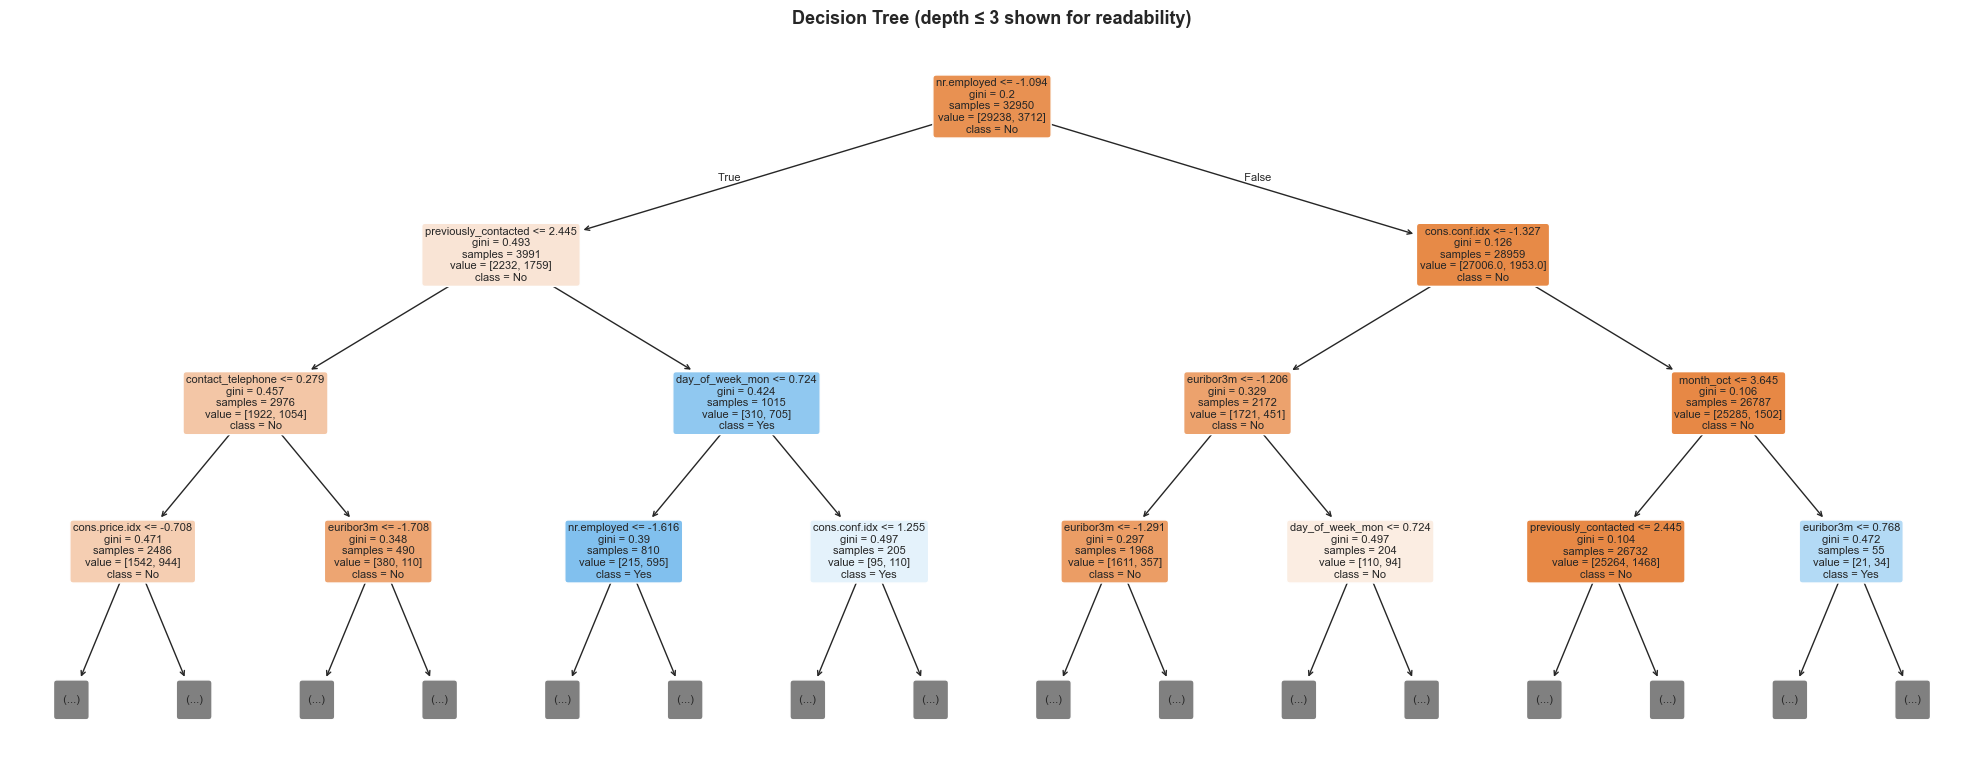

In [32]:
# Decision Tree visualization — best tuned tree (max depth for readability)
best_dt = dt_grid.best_estimator_
# Create a shallow version for visualization if best depth is large
viz_depth = min(best_dt.max_depth if best_dt.max_depth else 4, 4)
dt_viz = DecisionTreeClassifier(max_depth=viz_depth, random_state=42,
                                 criterion=dt_grid.best_params_['criterion'],
                                 min_samples_split=dt_grid.best_params_['min_samples_split'],
                                 min_samples_leaf=dt_grid.best_params_['min_samples_leaf'])
dt_viz.fit(X_train_scaled, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz, feature_names=X_train.columns, class_names=['No', 'Yes'],
          filled=True, rounded=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title(f'Decision Tree (depth ≤ 3 shown for readability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.8 Feature Importances

The top 15 features driving the Decision Tree's predictions are ranked by importance. Feature importance measures how much each feature contributes to reducing impurity across all splits in the tree.

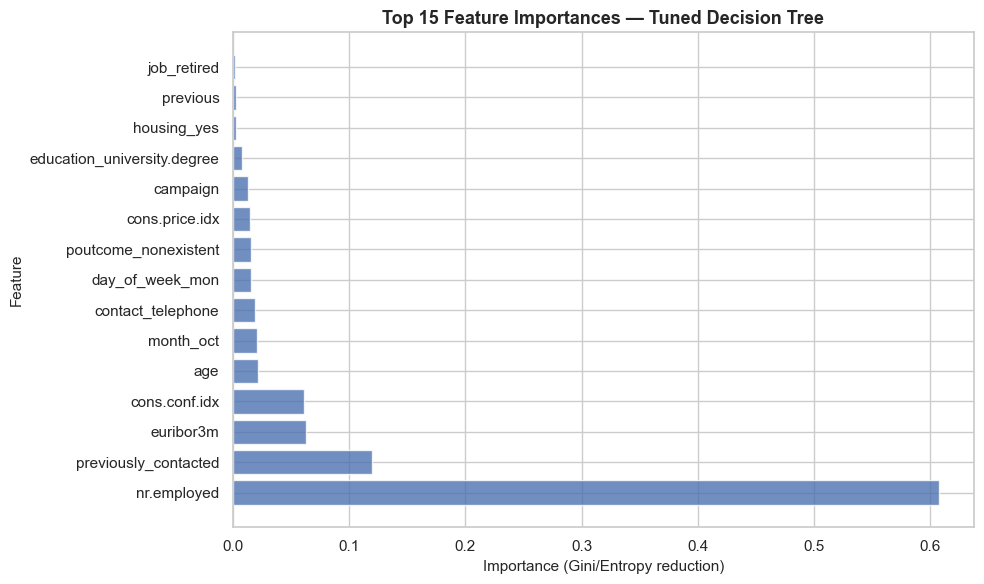

In [33]:
# Feature importances from Decision Tree
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#4C72B0', alpha=0.8)
ax.set_title('Top 15 Feature Importances — Tuned Decision Tree', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini/Entropy reduction)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

### 9.9 Final Model Comparison

The performance of the default and tuned versions of each model are compared side by side to quantify the improvement achieved through hyperparameter tuning.

In [34]:
# Final comparison: Default vs Tuned
print('=== FINAL MODEL COMPARISON SUMMARY ===')
print(f'\n{"Model":<35} {"Default AUC":>12} {"Tuned AUC":>10} {"Improvement":>12}')
print('-' * 72)

default_aucs = {}
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    default_aucs[name] = roc_auc_score(y_test, y_prob)

model_map = {
    'Logistic Regression': 'Logistic Regression (Tuned)',
    'K-Nearest Neighbors': 'KNN (Tuned)',
    'Decision Tree':       'Decision Tree (Tuned)',
    'SVM':                 'SVM (Tuned)'
}

for def_name, tuned_name in model_map.items():
    def_auc = default_aucs[def_name]
    tuned_row = tuned_df[tuned_df['Model'] == tuned_name].iloc[0]
    tuned_auc = tuned_row['Test ROC-AUC']
    improvement = tuned_auc - def_auc
    print(f'{def_name:<35} {def_auc:>12.4f} {tuned_auc:>10.4f} {improvement:>+12.4f}')

=== FINAL MODEL COMPARISON SUMMARY ===

Model                                Default AUC  Tuned AUC  Improvement
------------------------------------------------------------------------
Logistic Regression                       0.8008     0.8015      +0.0007
K-Nearest Neighbors                       0.7351     0.7835      +0.0484
Decision Tree                             0.6261     0.8043      +0.1782
SVM                                       0.7284     0.7308      +0.0024


## 10. Findings & Recommendations

---

### Business Context Recap

A Portuguese bank wants to predict which clients will subscribe to a term deposit following phone-based marketing. With only ~11.3% of clients subscribing, the bank is spending resources on ~88.7% non-converters. A good classifier enables **targeted outreach**, reducing costs and improving conversion rates.

---

### Model Performance Summary

| Model | Train Accuracy | Test Accuracy | Test ROC-AUC | CV ROC-AUC |
|-------|---------------|--------------|-------------|------------|
| Baseline (majority class) | 0.8873 | 0.8873 | 0.500 | — |
| Logistic Regression (Tuned) | 0.9002 | 0.9020 | 0.8015 | 0.7894 ± 0.0063 |
| KNN (Tuned) | 0.9011 | 0.9012 | 0.7835 | 0.7666 ± 0.0077 |
| Decision Tree (Tuned) | 0.9049 | 0.9013 | 0.8043 | 0.7868 ± 0.0030 |
| SVM (Tuned) | 0.8982 | 0.8994 | 0.7308 | 0.7195 ± 0.0090 |

### Winner: Logistic Regression (Tuned)

Based on the model performance summary, Decision Tree (Tuned) and Logistic Regression (Tuned) are virtually tied on test ROC-AUC (0.8043 vs 0.8015), a difference of only 0.0028. The cross-validation ROC-AUC further confirms this — Logistic Regression achieves a marginally higher CV mean (0.7894 vs 0.7868), while the Decision Tree shows slightly more consistency across folds (standard deviation of 0.0030 vs 0.0063). Given how close these results are, the choice of recommended model shifts to practical deployment considerations.

Logistic Regression is the **recommended model** for this business problem for the following reasons:

1. **Competitive performance**: Despite being a simpler model, Logistic Regression matches the Decision Tree's test ROC-AUC within a margin of 0.0028, which is not practically significant. It also achieves a marginally higher cross-validation mean (0.7894 vs 0.7868), suggesting it generalizes slightly better across different subsets of the data.

2. **Coefficient interpretability**: Logistic Regression coefficients provide a precise quantitative measure of each feature's contribution to the prediction. For example, a large positive coefficient for `poutcome_success` directly tells the bank that prior campaign success is a strong driver of subscription. This level of precision is useful for reporting and feature analysis in a way that a Decision Tree cannot match at scale.

3. **Stability**: In general, Decision Trees are sensitive to small changes in training data — a minor shift in the dataset can result in a significantly different tree structure. Logistic Regression is more stable and produces consistent predictions when applied to new campaign data from future marketing efforts.

4. **Efficiency**: In general, Logistic Regression is significantly faster to train and score new clients in production. As the bank scales its campaigns and scores thousands of clients in real time, this efficiency advantage becomes increasingly important.

5. **Simplicity**: Logistic Regression requires fewer hyperparameters to tune — as seen in Section 9.1, only `C` and `penalty` are explored, compared to four parameters for the Decision Tree in Section 9.3. A simpler model that performs equally well is easier to maintain and audit over time.

---

### Key Actionable Insights for the Bank

**1. Prioritize clients with prior subscription history**
Clients who successfully subscribed in a previous campaign convert at approximately six times the overall average rate. Both the subscription rate analysis and the model confirm this as the strongest predictor of future subscription. These clients should be prioritized in future campaigns.

**2. Use cellular contact over telephone**
Clients reached via cellular contact convert at a higher rate than those contacted on a fixed telephone line, as observed in the subscription rate analysis and confirmed by the model. Obtaining cellular numbers for telephone-only clients would improve campaign effectiveness.

**3. Focus campaigns in high-conversion months**
The subscription rate analysis shows that March, September, October, and December consistently produce above-average subscription rates despite lower call volumes. May, which accounts for the highest call volume, produces below-average conversions. Shifting campaign intensity toward the higher-converting months would improve overall efficiency.

**4. Reduce excessive contact attempts**
Clients who subscribed were typically contacted fewer times than those who did not, as shown in the distribution analysis. Limiting the number of contact attempts per client would reduce wasted resources on clients unlikely to convert.

**5. Monitor economic conditions**
Both the data distributions and the model show that lower interest rates and employment variation rates are associated with higher subscription rates. Tracking these economic indicators can help the bank identify periods when clients are more receptive to subscribing.

**6. Target students and retirees**
The subscription rate analysis shows that students and retired clients both display above-average subscription rates. Tailoring campaign messaging for these segments could improve conversion within these groups.

---

### Next Steps & Recommendations

**1. Deploy with probability threshold tuning**
The recommended Logistic Regression model outputs a subscription probability for each client rather than a simple yes/no prediction. The default threshold of 0.5 may not be optimal given the class imbalance. Evaluating different threshold values based on the cost of a wasted call versus the revenue from a successful subscription would allow the bank to align the model with its business priorities.

**2. Real-time scoring pipeline**
Integrating the model into the bank's customer management system would allow agents to see a subscription probability score for each client before making a call, enabling real-time prioritization of outreach.

**3. A/B test model-guided vs. random outreach**
Running a controlled experiment comparing model-guided targeting against traditional methods would validate whether the model delivers measurable improvements in real-world campaign performance.

**4. Address class imbalance**
Applying oversampling techniques or adjusting the model to penalize misclassification of subscribers more heavily could improve the model's ability to identify potential subscribers in future campaigns.

**5. Explore ensemble methods**
Benchmarking more advanced methods such as Random Forest and Gradient Boosting against the current model could reveal whether further performance gains are achievable.